In [1]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
import h5py
from tensorflow.keras.models import Model
import pandas as pd
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import *
from tensorflow.keras import backend as keras
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.models import load_model
from tensorflow.keras.metrics import Recall
from tensorflow.keras.applications.vgg16 import decode_predictions
from tensorflow.keras.applications.vgg16 import preprocess_input
from sklearn.metrics import confusion_matrix,accuracy_score,recall_score
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# figure

In [2]:
def plot_CM(true_label, pred_label, title = ' '):
    
    # Creates a confusion matrix
    cm = confusion_matrix(true_label, pred_label) 
    cm[0, 0], cm[1, 1] = cm[1, 1], cm[0, 0]
    # Transform to df for easier plotting
    cm_df = pd.DataFrame(cm,
                         index = ['Positive', 'Negative'], 
                         columns = ['Positive', 'Negative'])

    plt.figure(figsize=(5.5,4))
    sns.heatmap(cm_df, annot=True, fmt="d")

    plt.title(title )
    plt.ylabel('Predicted label')
    plt.xlabel('True label')
    plt.show()

# GPU

In [3]:
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"
cfg = tf.compat.v1.ConfigProto() 
cfg.gpu_options.visible_device_list="0"
cfg.gpu_options.allow_growth=True
cfg.gpu_options.per_process_gpu_memory_fraction = 0.7# 使用50%的GPU暫存  
session = tf.compat.v1.Session(config=cfg )

In [4]:
def solve_cudnn_error():
    gpus = tf.config.experimental.list_physical_devices('GPU')
    if gpus:
        try:
            # Currently, memory growth needs to be the same across GPUs
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
            logical_gpus = tf.config.experimental.list_logical_devices('GPU')
            print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
        except RuntimeError as e:
            # Memory growth must be set before GPUs have been initialized
            print(e)

In [5]:
solve_cudnn_error()

1 Physical GPUs, 1 Logical GPUs


## Data

In [6]:
def train_generator(batch_size, train_path, aug_dict,
        image_color_mode="rgb",
        target_size=(224,224),
        seed=1):
    '''
    can generate image and mask at the same time use the same seed for
    image_datagen and mask_datagen to ensure the transformation for image
    and mask is the same if you want to visualize the results of generator,
    set save_to_dir = "your path"
    '''
    image_datagen = ImageDataGenerator(**aug_dict)
    
    image_generator = image_datagen.flow_from_directory(
        train_path,
        class_mode = "binary",
        color_mode = image_color_mode,
        target_size = target_size,
        batch_size = batch_size,
        seed = seed)
    for (img, labels) in image_generator:
        yield (img,labels)

In [7]:
def test_generator(batch_size,test_path,
        image_color_mode="rgb",
        target_size=(224,224),
        seed=1):
    test_datagen = ImageDataGenerator(rescale=1./255) 
    
    test_generator = test_datagen.flow_from_directory(
        test_path,
        class_mode = "binary",
        color_mode = image_color_mode,
        target_size = target_size,
        batch_size = batch_size)
    return test_generator

In [8]:
train_data_folder1 = 'train/AP/'
train_data_folder2="train/LC/"
train_files1= [file for file in os.listdir(train_data_folder1) if file.lower().endswith('.jpg')]
train_files2= [file for file in os.listdir(train_data_folder2) if file.lower().endswith('.jpg')]
(len(train_files1), \
 len(train_files2))

(670, 573)

## Train Model

In [11]:
BATCH_SIZE=16
EPOCHS=100
train_generator_args = dict(rescale=1./255,
                            rotation_range=4.5,
                            width_shift_range=0.05,
                            height_shift_range=0.05,
                            shear_range=0.05,
                            zoom_range=0.05,
                            fill_mode='nearest')

train_gen = train_generator(BATCH_SIZE,
                            "train/",
                            train_generator_args,
                            target_size=(224,224))
validation_data =train_generator(BATCH_SIZE,
                            "validation/",
                            train_generator_args,
                            target_size=(224,224))


In [10]:
base_model = VGG16(weights='imagenet', include_top=False , input_shape=(224,224,3))
# 凍結預訓練模型的層

# 添加自定義的頂層
x = base_model.output
x = Flatten()(x)
x = Dense(1024, activation='relu')(x)
x = Dense(512, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)  # num_classes 是你的類別數

model = Model(inputs=base_model.input, outputs=output )

for layer in base_model.layers:
    layer.trainable = False

# 編譯模型
model.compile(optimizer=SGD(lr=0.0001, momentum=0.9), loss='binary_crossentropy', metrics=['accuracy',Recall()])

model.summary()
model_checkpoint = ModelCheckpoint('gallbladder_VGG16_positive.hdf5', 
                                   monitor='loss', 
                                   verbose=1, 
                                   save_best_only=True)

history = model.fit_generator(train_gen,
                              steps_per_epoch=(len(train_files1)+len(train_files2))/ BATCH_SIZE, 
                              epochs=EPOCHS, 
                              callbacks=[model_checkpoint],
                               validation_data = validation_data,
                              validation_steps =10)


Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 224, 224, 3)]     0         
_________________________________________________________________
block1_conv1 (Conv2D)        (None, 224, 224, 64)      1792      
_________________________________________________________________
block1_conv2 (Conv2D)        (None, 224, 224, 64)      36928     
_________________________________________________________________
block1_pool (MaxPooling2D)   (None, 112, 112, 64)      0         
_________________________________________________________________
block2_conv1 (Conv2D)        (None, 112, 112, 128)     73856     
_________________________________________________________________
block2_conv2 (Conv2D)        (None, 112, 112, 128)     147584    
_________________________________________________________________
block2_pool (MaxPooling2D)   (None, 56, 56, 128)       0     

78/77 [==============================] - 48s 617ms/step - loss: 0.3176 - accuracy: 0.8656 - recall: 0.8028 - val_loss: 0.4116 - val_accuracy: 0.7746 - val_recall: 0.7188
Epoch 14/100
77/77 [============================>.] - ETA: 0s - loss: 0.3220 - accuracy: 0.8636 - recall: 0.8102
Epoch 00014: loss did not improve from 0.31819
78/77 [==============================] - 48s 611ms/step - loss: 0.3200 - accuracy: 0.8640 - recall: 0.8098 - val_loss: 0.3981 - val_accuracy: 0.7958 - val_recall: 0.6613
Epoch 15/100
77/77 [============================>.] - ETA: 0s - loss: 0.3182 - accuracy: 0.8612 - recall: 0.8018
Epoch 00015: loss improved from 0.31819 to 0.31743, saving model to gallbladder_VGG16_positive.hdf5
78/77 [==============================] - 48s 617ms/step - loss: 0.3171 - accuracy: 0.8616 - recall: 0.8010 - val_loss: 0.3666 - val_accuracy: 0.8028 - val_recall: 0.7143
Epoch 16/100
77/77 [============================>.] - ETA: 0s - loss: 0.3075 - accuracy: 0.8774 - recall: 0.8216
Epoc

77/77 [============================>.] - ETA: 0s - loss: 0.2673 - accuracy: 0.8896 - recall: 0.8664
Epoch 00037: loss did not improve from 0.25820
78/77 [==============================] - 48s 617ms/step - loss: 0.2662 - accuracy: 0.8898 - recall: 0.8656 - val_loss: 0.3227 - val_accuracy: 0.8169 - val_recall: 0.7727
Epoch 38/100
77/77 [============================>.] - ETA: 0s - loss: 0.2548 - accuracy: 0.8961 - recall: 0.8468
Epoch 00038: loss improved from 0.25820 to 0.25624, saving model to gallbladder_VGG16_positive.hdf5
78/77 [==============================] - 48s 622ms/step - loss: 0.2569 - accuracy: 0.8954 - recall: 0.8464 - val_loss: 0.2777 - val_accuracy: 0.8803 - val_recall: 0.9062
Epoch 39/100
77/77 [============================>.] - ETA: 0s - loss: 0.2486 - accuracy: 0.8994 - recall: 0.8647
Epoch 00039: loss improved from 0.25624 to 0.25082, saving model to gallbladder_VGG16_positive.hdf5
78/77 [==============================] - 48s 620ms/step - loss: 0.2518 - accuracy: 0.89

Epoch 61/100
77/77 [============================>.] - ETA: 0s - loss: 0.2381 - accuracy: 0.9026 - recall: 0.8657
Epoch 00061: loss did not improve from 0.22824
78/77 [==============================] - 48s 612ms/step - loss: 0.2392 - accuracy: 0.9019 - recall: 0.8656 - val_loss: 0.3198 - val_accuracy: 0.8872 - val_recall: 0.9167
Epoch 62/100
77/77 [============================>.] - ETA: 0s - loss: 0.2490 - accuracy: 0.8945 - recall: 0.8682
Epoch 00062: loss did not improve from 0.22824
78/77 [==============================] - 48s 613ms/step - loss: 0.2471 - accuracy: 0.8954 - recall: 0.8691 - val_loss: 0.3037 - val_accuracy: 0.8647 - val_recall: 0.8305
Epoch 63/100
77/77 [============================>.] - ETA: 0s - loss: 0.2302 - accuracy: 0.9083 - recall: 0.8768
Epoch 00063: loss did not improve from 0.22824
78/77 [==============================] - 48s 613ms/step - loss: 0.2300 - accuracy: 0.9083 - recall: 0.8761 - val_loss: 0.3977 - val_accuracy: 0.8647 - val_recall: 0.9310
Epoch 64/1

Epoch 86/100
77/77 [============================>.] - ETA: 0s - loss: 0.2074 - accuracy: 0.9196 - recall: 0.8912
Epoch 00086: loss improved from 0.21248 to 0.21010, saving model to gallbladder_VGG16_positive.hdf5
78/77 [==============================] - 48s 618ms/step - loss: 0.2113 - accuracy: 0.9187 - recall: 0.8901 - val_loss: 0.2939 - val_accuracy: 0.8873 - val_recall: 0.9355
Epoch 87/100
77/77 [============================>.] - ETA: 0s - loss: 0.1997 - accuracy: 0.9213 - recall: 0.8942
Epoch 00087: loss improved from 0.21010 to 0.19889, saving model to gallbladder_VGG16_positive.hdf5
78/77 [==============================] - 48s 618ms/step - loss: 0.1985 - accuracy: 0.9220 - recall: 0.8953 - val_loss: 0.2588 - val_accuracy: 0.8873 - val_recall: 0.8939
Epoch 88/100
77/77 [============================>.] - ETA: 0s - loss: 0.2142 - accuracy: 0.9123 - recall: 0.8891
Epoch 00088: loss did not improve from 0.19889
78/77 [==============================] - 48s 613ms/step - loss: 0.2149 - a

## Loss history

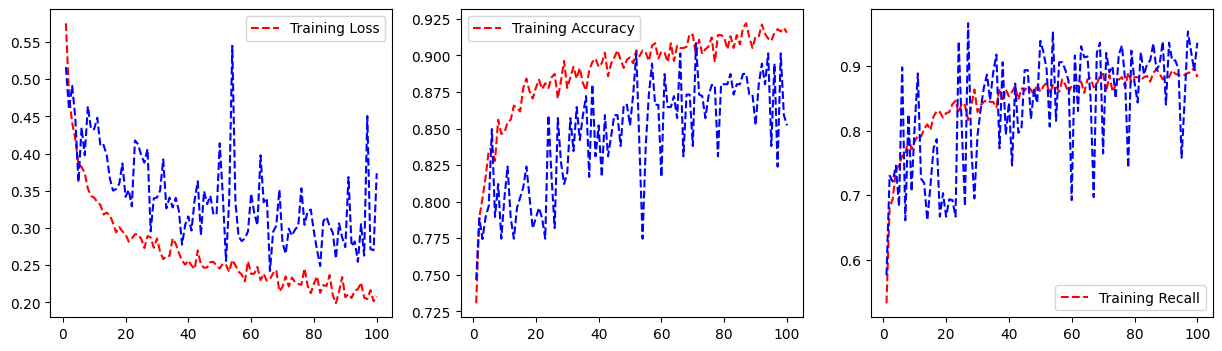

In [11]:
fig, axs = plt.subplots(1, 3, figsize = (15, 4))

training_loss = history.history['loss']
training_accuracy = history.history['accuracy']
training_recall = history.history['recall']
val_loss = history.history['val_loss']
val_accuracy = history.history['val_accuracy']
val_recall = history.history['val_recall']
epoch_count = range(1, len(training_loss) + 1)

axs[0].plot(epoch_count, training_loss, 'r--')
axs[0].plot(epoch_count, val_loss, 'b--')
axs[0].legend(['Training Loss'])

axs[1].plot(epoch_count, training_accuracy, 'r--')
axs[1].plot(epoch_count, val_accuracy, 'b--')
axs[1].legend(['Training Accuracy'])

axs[2].plot(epoch_count, training_recall, 'r--')
axs[2].plot(epoch_count, val_recall, 'b--')
axs[2].legend(['Training Recall'])

## Model Test

In [9]:
model = load_model('gallbladder_VGG16_positive2.hdf5', compile=True)

In [10]:
def test_predict_load_image(test_file, target_size=(224,224)):
    img = cv2.imread(test_file, cv2.IMREAD_COLOR)
    img = img / 255
    img = cv2.resize(img, target_size)

    img = np.reshape(img,(1,) + img.shape)
    return img

In [11]:
def test_predict_generator(test_files, test_data_folder,target_size=(224,224)):
    for test_file in test_files:
        test_file=os.path.join(test_data_folder,test_file)
        yield test_predict_load_image(test_file, target_size)

7/7 [==============================] - 0s 56ms/step
predicted_true_label
accuracy: 1.0
1347952 預測正確
9/9 [==============================] - 0s 21ms/step
predicted_true_label
accuracy: 1.0
1564057 預測正確
11/11 [==============================] - 0s 20ms/step
predicted_true_label
accuracy: 1.0
1582880 預測正確
11/11 [==============================] - 0s 21ms/step
predicted_true_label
accuracy: 1.0
1675769 預測正確
13/13 [==============================] - 0s 21ms/step
predicted_true_label
1802898_20240404_CT_4_32_32.jpg
accuracy: 0.9230769230769231


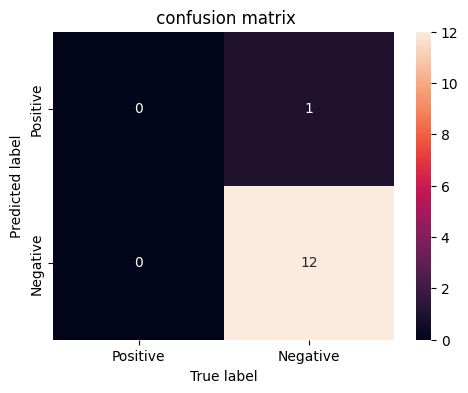

10/10 [==============================] - 0s 20ms/step
predicted_true_label
accuracy: 1.0
1829243 預測正確
9/9 [==============================] - 0s 21ms/step
predicted_true_label
accuracy: 1.0
1991081 預測正確
9/9 [==============================] - 0s 21ms/step
predicted_true_label
accuracy: 1.0
2028795 預測正確
6/6 [==============================] - 0s 21ms/step
predicted_true_label
accuracy: 1.0
2133813 預測正確
10/10 [==============================] - 0s 21ms/step
predicted_true_label
accuracy: 1.0
2284505 預測正確
11/11 [==============================] - 0s 20ms/step
predicted_true_label
accuracy: 1.0
2331067 預測正確
6/6 [==============================] - 0s 21ms/step
predicted_true_label
accuracy: 1.0
2396949 預測正確
11/11 [==============================] - 0s 21ms/step
predicted_true_label
accuracy: 1.0
2431413 預測正確
7/7 [==============================] - 0s 21ms/step
predicted_true_label
accuracy: 1.0
2446816 預測正確
7/7 [==============================] - 0s 21ms/step
predicted_true_label
accuracy: 1.0
24979

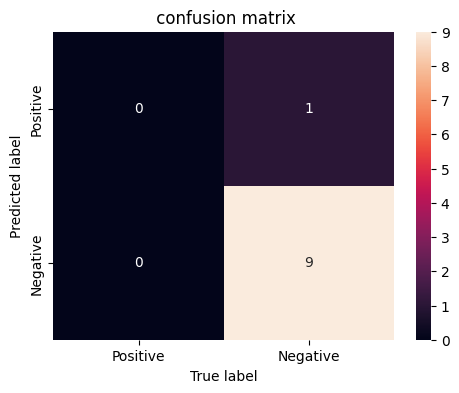

8/8 [==============================] - 0s 21ms/step
predicted_true_label
accuracy: 1.0
9016548 預測正確
10/10 [==============================] - 0s 21ms/step
predicted_true_label
accuracy: 1.0
9016611 預測正確
9/9 [==============================] - 0s 21ms/step
predicted_true_label
accuracy: 1.0
9017008 預測正確
11/11 [==============================] - 0s 21ms/step
predicted_true_label
9017162_20231027_CT_4_24_24.jpg
9017162_20231027_CT_4_26_26.jpg
accuracy: 0.8181818181818182


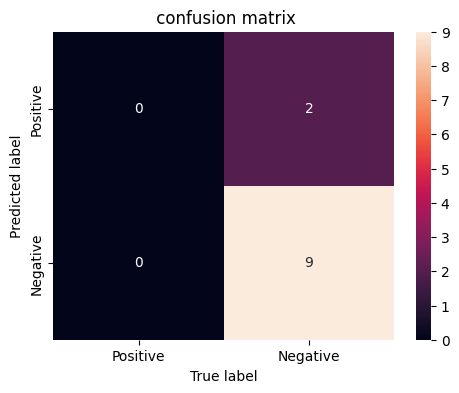

7/7 [==============================] - 0s 21ms/step
predicted_true_label
accuracy: 1.0
9017369 預測正確
11/11 [==============================] - 0s 20ms/step
predicted_true_label
accuracy: 1.0
9017647 預測正確
10/10 [==============================] - 0s 21ms/step
predicted_true_label
accuracy: 1.0
9023009 預測正確
10/10 [==============================] - 0s 21ms/step
predicted_true_label
accuracy: 1.0
9037563 預測正確
7/7 [==============================] - 0s 21ms/step
predicted_true_label
accuracy: 1.0
9037975 預測正確
9/9 [==============================] - 0s 21ms/step
predicted_true_label
accuracy: 1.0
9038189 預測正確
7/7 [==============================] - 0s 21ms/step
predicted_true_label
accuracy: 1.0
9039414 預測正確
14/14 [==============================] - 0s 21ms/step
predicted_true_label
accuracy: 1.0
9041102 預測正確
10/10 [==============================] - 0s 21ms/step
predicted_true_label
accuracy: 1.0
9042038 預測正確
all_test
all_accuracy: 0.991304347826087


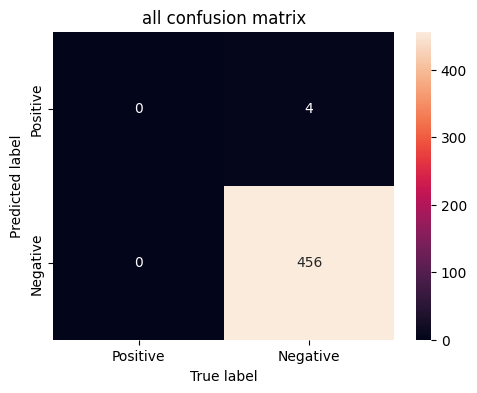

預測急性膽囊炎陽性
1802898
9008772
9017162
預測急性膽囊炎陰性
1347952
1564057
1582880
1675769
1829243
1991081
2028795
2133813
2284505
2331067
2396949
2431413
2446816
2497995
2545482
2562169
2563589
2602273
2692169
2786507
2801783
2852572
2871128
2898131
2956565
3076161
3171602
3189019
3264705
3300278
3342114
3351025
3371551
3395616
5162471
9008698
9016548
9016611
9017008
9017369
9017647
9023009
9037563
9037975
9038189
9039414
9041102
9042038


In [16]:
first_folder="./test_case/AP/"
folder=os.listdir(first_folder)
all_true_classes=[]
all_predicted_classes=[]
AP_AP_class=[]
AP_LC_class=[]

for test in folder:
    bool_num=False
    true_classes=[]
    false_label_folder="./test_case/AP/{}/AP".format(test)
    false_files=[file for file in os.listdir(false_label_folder) if file.lower().endswith('.jpg')]
    file_num=(len(false_files))

    test_data_folder="./test_case/AP/{}/image".format(test)
    test_files=[file for file in os.listdir(test_data_folder) if file.lower().endswith('.jpg')]
    test_predict_gen = test_predict_generator(test_files, test_data_folder,target_size=(224,224))
    
    results = model.predict_generator(test_predict_gen, len(test_files), verbose=1)
    
    threshold = 0.85  # 可以根据需要调整
    
    # 将预测结果解释为类别
    predicted_classes = [1 if result > threshold else 0 for result in results]
    #print(test_files)
    #print("false_label")
    a=1
    for i in range(0,file_num):
        file_name=test_files[i]
        if file_name in false_files:
            #print(a,file_name)
            #print(results[i])
            true_classes.append(0)
        else:
            true_classes.append(1)
        a+=1
    print("predicted_true_label")
    index=0
    for i in predicted_classes:
        if i==1:
            print(test_files[index])
        index=index+1
    for i in predicted_classes:
        if i==1:
            bool_num=True
            break
    if bool_num:
        AP_LC_class.append(test)
    else:
        AP_AP_class.append(test)
    accuracy = accuracy_score(true_classes, predicted_classes)
    print("accuracy:",accuracy)
    all_true_classes=all_true_classes+true_classes

    all_predicted_classes=all_predicted_classes+predicted_classes
    #recall = recall_score(true_classes, predicted_classes)
    #print("recall:",recall)
    try:
        plot_CM(true_classes, predicted_classes," confusion matrix")
        
        
    except:
        print(test,"預測正確")        
        pass
    
print("all_test")
accuracy = accuracy_score(all_true_classes, all_predicted_classes)
print("all_accuracy:",accuracy)
#recall = recall_score(all_true_classes, all_predicted_classes)
#print("all_recall:",recall)
plot_CM(all_true_classes, all_predicted_classes,"all confusion matrix")
print("預測急性膽囊炎陽性")
for i in AP_LC_class:
    print(i)
print("預測急性膽囊炎陰性")
for i in AP_AP_class:
    print(i)

8/8 [==============================] - 0s 62ms/step
predicted_true_label
042736_20240429_CT_12_24_24.jpg
042736_20240429_CT_12_25_25.jpg
042736_20240429_CT_12_26_26.jpg
042736_20240429_CT_12_27_27.jpg
042736_20240429_CT_12_28_28.jpg
042736_20240429_CT_12_29_29.jpg
accuracy: 0.75


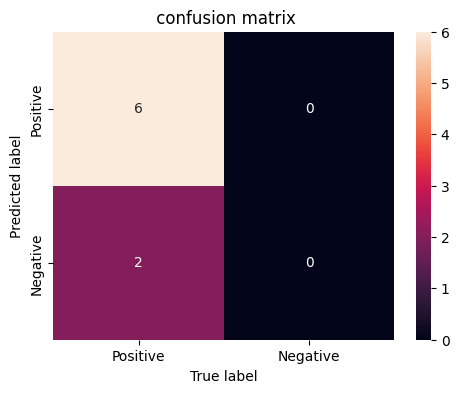

8/8 [==============================] - 0s 21ms/step
predicted_true_label
1076468_20240429_CT_4_23_21.jpg
1076468_20240429_CT_4_24_22.jpg
1076468_20240429_CT_4_25_23.jpg
1076468_20240429_CT_4_26_24.jpg
1076468_20240429_CT_4_27_25.jpg
1076468_20240429_CT_4_28_26.jpg
accuracy: 0.75


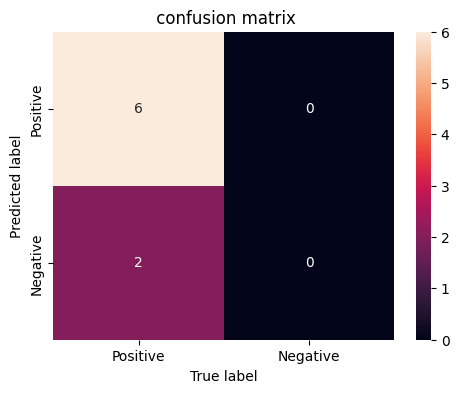

16/16 [==============================] - 0s 20ms/step
predicted_true_label
1170119_20230825_CT_2_23_20.jpg
1170119_20230825_CT_2_24_21.jpg
1170119_20230825_CT_2_25_22.jpg
1170119_20230825_CT_2_26_23.jpg
1170119_20230825_CT_2_27_24.jpg
1170119_20230825_CT_2_28_25.jpg
1170119_20230825_CT_2_29_26.jpg
1170119_20230825_CT_2_30_27.jpg
1170119_20230825_CT_2_31_28.jpg
1170119_20230825_CT_2_32_29.jpg
1170119_20230825_CT_2_33_30.jpg
1170119_20230825_CT_2_34_31.jpg
1170119_20230825_CT_2_35_32.jpg
1170119_20230825_CT_2_36_33.jpg
1170119_20230825_CT_2_37_34.jpg
accuracy: 0.9375


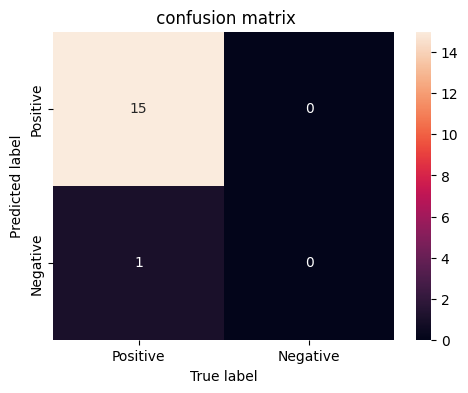

7/7 [==============================] - 0s 21ms/step
predicted_true_label
accuracy: 0.0


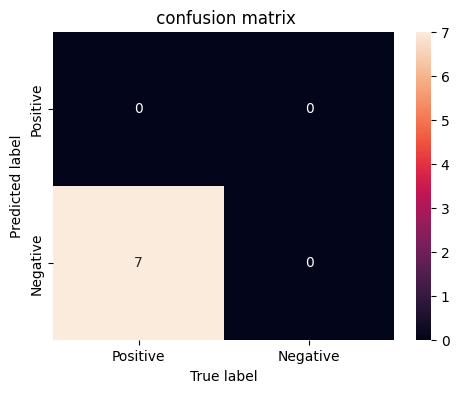

13/13 [==============================] - 0s 21ms/step
predicted_true_label
1276685_20240506_CT_2_20_17.jpg
1276685_20240506_CT_2_21_18.jpg
1276685_20240506_CT_2_22_19.jpg
1276685_20240506_CT_2_23_20.jpg
1276685_20240506_CT_2_24_21.jpg
1276685_20240506_CT_2_25_22.jpg
1276685_20240506_CT_2_26_23.jpg
1276685_20240506_CT_2_27_24.jpg
accuracy: 0.6153846153846154


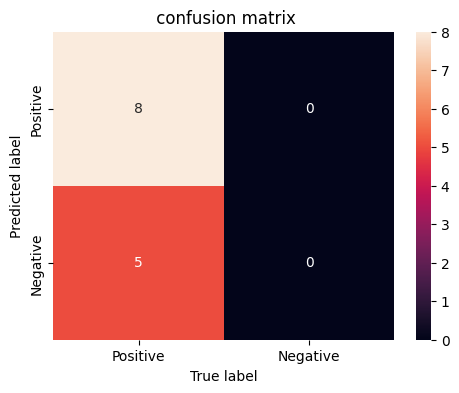

16/16 [==============================] - 0s 21ms/step
predicted_true_label
1482601_20231001_CT_7_21_21.jpg
1482601_20231001_CT_7_22_22.jpg
1482601_20231001_CT_7_23_23.jpg
1482601_20231001_CT_7_24_24.jpg
1482601_20231001_CT_7_25_25.jpg
1482601_20231001_CT_7_26_26.jpg
1482601_20231001_CT_7_27_27.jpg
1482601_20231001_CT_7_28_28.jpg
1482601_20231001_CT_7_29_29.jpg
1482601_20231001_CT_7_30_30.jpg
1482601_20231001_CT_7_31_31.jpg
1482601_20231001_CT_7_32_32.jpg
1482601_20231001_CT_7_33_33.jpg
1482601_20231001_CT_7_34_34.jpg
accuracy: 0.875


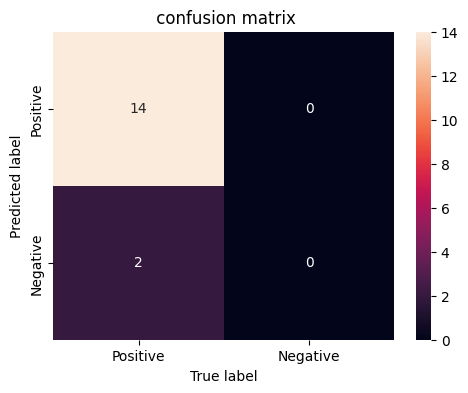

8/8 [==============================] - 0s 21ms/step
predicted_true_label
1539408_20230820_CT_8_19_19.jpg
1539408_20230820_CT_8_20_20.jpg
1539408_20230820_CT_8_21_21.jpg
1539408_20230820_CT_8_22_22.jpg
1539408_20230820_CT_8_23_23.jpg
1539408_20230820_CT_8_24_24.jpg
accuracy: 0.75


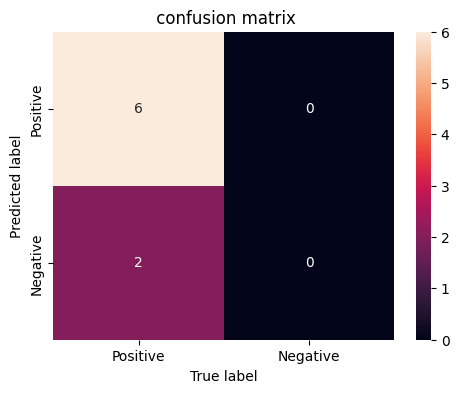

12/12 [==============================] - 0s 20ms/step
predicted_true_label
1581895_20240503_CT_7_28_28.jpg
1581895_20240503_CT_7_29_29.jpg
1581895_20240503_CT_7_30_30.jpg
1581895_20240503_CT_7_31_31.jpg
1581895_20240503_CT_7_32_32.jpg
1581895_20240503_CT_7_33_33.jpg
1581895_20240503_CT_7_34_34.jpg
1581895_20240503_CT_7_35_35.jpg
1581895_20240503_CT_7_36_36.jpg
accuracy: 0.75


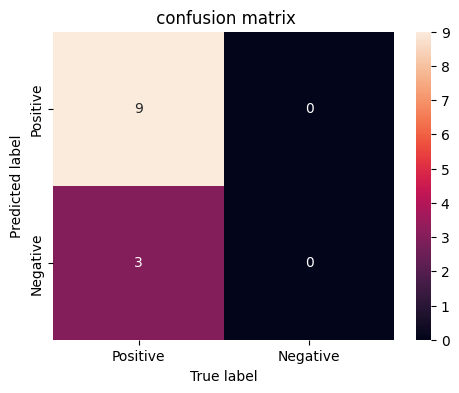

16/16 [==============================] - 0s 20ms/step
predicted_true_label
accuracy: 0.0


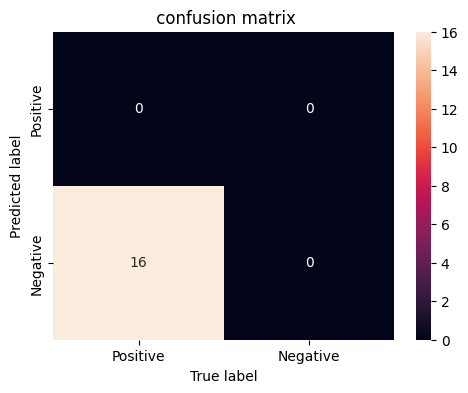

14/14 [==============================] - 0s 21ms/step
predicted_true_label
1758897_20240416_CT_4_27_23.jpg
1758897_20240416_CT_4_28_24.jpg
1758897_20240416_CT_4_29_25.jpg
1758897_20240416_CT_4_30_26.jpg
1758897_20240416_CT_4_31_27.jpg
1758897_20240416_CT_4_32_28.jpg
1758897_20240416_CT_4_33_29.jpg
1758897_20240416_CT_4_34_30.jpg
1758897_20240416_CT_4_35_31.jpg
1758897_20240416_CT_4_36_32.jpg
accuracy: 0.7142857142857143


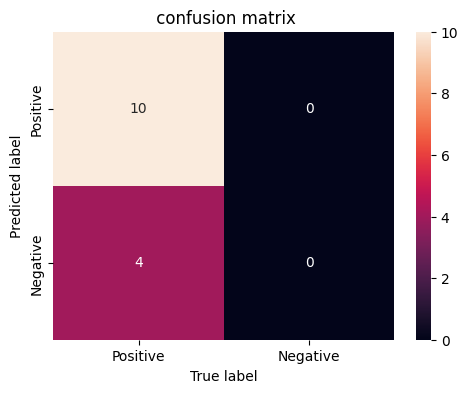

11/11 [==============================] - 0s 21ms/step
predicted_true_label
1760107_20230530_CT_4_26_26.jpg
1760107_20230530_CT_4_27_27.jpg
1760107_20230530_CT_4_28_28.jpg
1760107_20230530_CT_4_29_29.jpg
1760107_20230530_CT_4_30_30.jpg
1760107_20230530_CT_4_31_31.jpg
1760107_20230530_CT_4_32_32.jpg
1760107_20230530_CT_4_33_33.jpg
1760107_20230530_CT_4_34_34.jpg
1760107_20230530_CT_4_35_35.jpg
accuracy: 0.9090909090909091


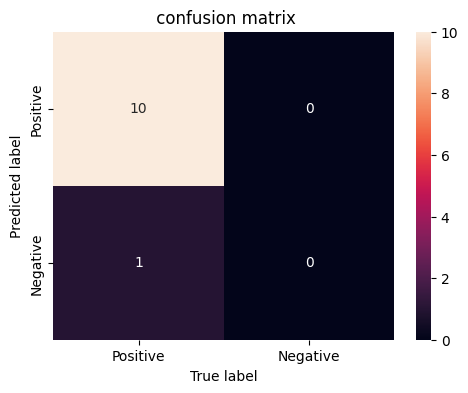

11/11 [==============================] - 0s 21ms/step
predicted_true_label
1842545_20230830_CT_10_24_24.jpg
1842545_20230830_CT_10_25_25.jpg
1842545_20230830_CT_10_26_26.jpg
1842545_20230830_CT_10_27_27.jpg
1842545_20230830_CT_10_28_28.jpg
1842545_20230830_CT_10_29_29.jpg
1842545_20230830_CT_10_30_30.jpg
1842545_20230830_CT_10_31_31.jpg
1842545_20230830_CT_10_32_32.jpg
1842545_20230830_CT_10_33_33.jpg
accuracy: 0.9090909090909091


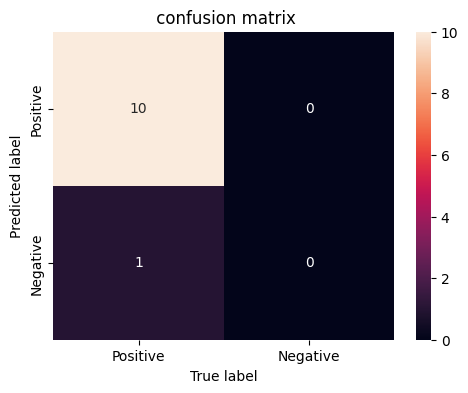

4/4 [==============================] - 0s 21ms/step
predicted_true_label
2030899_20230911_CT_3_21_21.jpg
2030899_20230911_CT_3_22_22.jpg
accuracy: 0.5


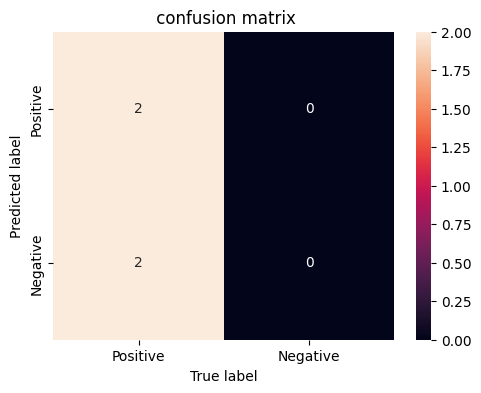

11/11 [==============================] - 0s 20ms/step
predicted_true_label
2099286_20230717_CT_4_30_30.jpg
2099286_20230717_CT_4_31_31.jpg
2099286_20230717_CT_4_32_32.jpg
2099286_20230717_CT_4_33_33.jpg
2099286_20230717_CT_4_34_34.jpg
2099286_20230717_CT_4_35_35.jpg
accuracy: 0.5454545454545454


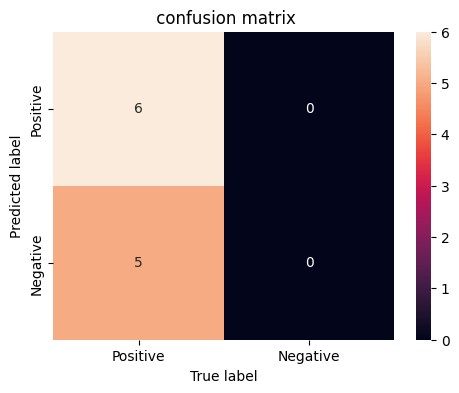

11/11 [==============================] - 0s 20ms/step
predicted_true_label
2117512_20230714_CT_4_31_29.jpg
2117512_20230714_CT_4_38_36.jpg
accuracy: 0.18181818181818182


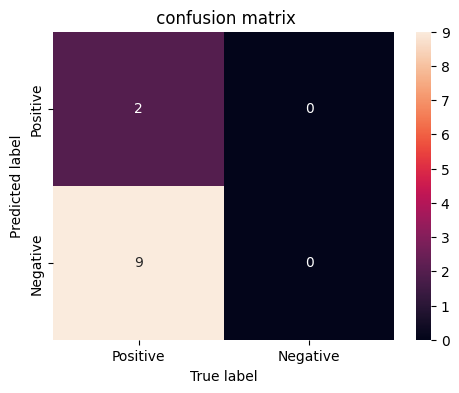

11/11 [==============================] - 0s 21ms/step
predicted_true_label
2180217_20240319_CT_9_28_20.jpg
2180217_20240319_CT_9_29_21.jpg
2180217_20240319_CT_9_30_22.jpg
2180217_20240319_CT_9_31_23.jpg
2180217_20240319_CT_9_32_24.jpg
2180217_20240319_CT_9_33_25.jpg
2180217_20240319_CT_9_34_26.jpg
2180217_20240319_CT_9_35_27.jpg
2180217_20240319_CT_9_36_28.jpg
2180217_20240319_CT_9_37_29.jpg
accuracy: 0.9090909090909091


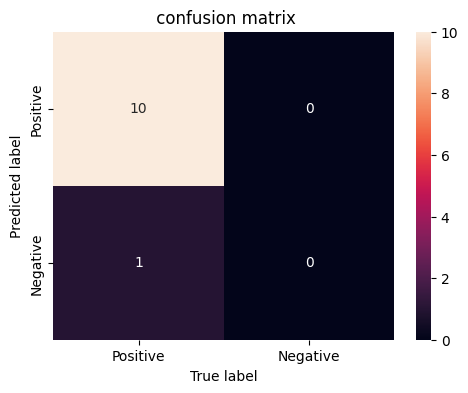

9/9 [==============================] - 0s 21ms/step
predicted_true_label
2254047_20230913_CT_7_34_34.jpg
accuracy: 0.1111111111111111


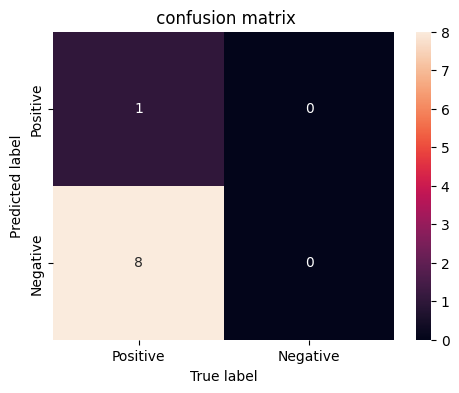

16/16 [==============================] - 0s 21ms/step
predicted_true_label
2305923_20240503_CT_4_19_19.jpg
2305923_20240503_CT_4_20_20.jpg
2305923_20240503_CT_4_22_22.jpg
2305923_20240503_CT_4_23_23.jpg
2305923_20240503_CT_4_24_24.jpg
2305923_20240503_CT_4_25_25.jpg
2305923_20240503_CT_4_27_27.jpg
2305923_20240503_CT_4_28_28.jpg
2305923_20240503_CT_4_29_29.jpg
2305923_20240503_CT_4_30_30.jpg
accuracy: 0.625


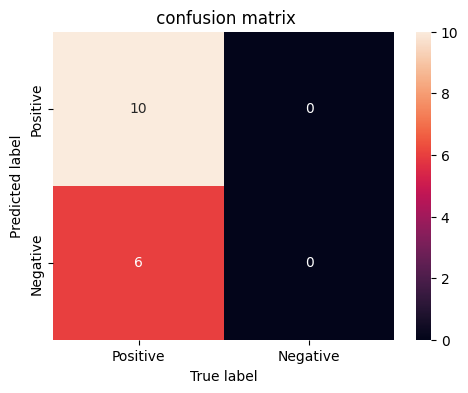

9/9 [==============================] - 0s 21ms/step
predicted_true_label
2370624_20231009_CT_4_18_15.jpg
2370624_20231009_CT_4_19_16.jpg
2370624_20231009_CT_4_20_17.jpg
2370624_20231009_CT_4_21_18.jpg
2370624_20231009_CT_4_22_19.jpg
2370624_20231009_CT_4_23_20.jpg
2370624_20231009_CT_4_24_21.jpg
2370624_20231009_CT_4_25_22.jpg
accuracy: 0.8888888888888888


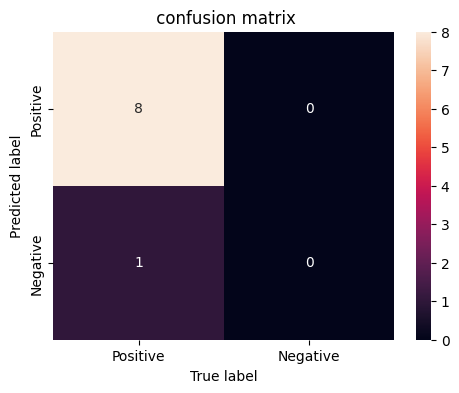

14/14 [==============================] - 0s 21ms/step
predicted_true_label
2409545_20230929_CT_4_40_33.jpg
2409545_20230929_CT_4_41_34.jpg
2409545_20230929_CT_4_42_35.jpg
accuracy: 0.21428571428571427


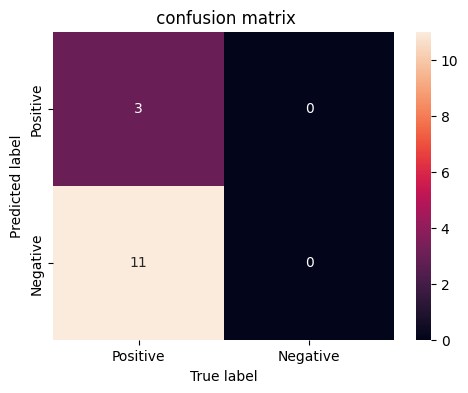

16/16 [==============================] - 0s 21ms/step
predicted_true_label
2469358_20240315_CT_4_19_18.jpg
2469358_20240315_CT_4_20_19.jpg
2469358_20240315_CT_4_24_23.jpg
2469358_20240315_CT_4_27_26.jpg
2469358_20240315_CT_4_28_27.jpg
2469358_20240315_CT_4_29_28.jpg
2469358_20240315_CT_4_30_29.jpg
accuracy: 0.4375


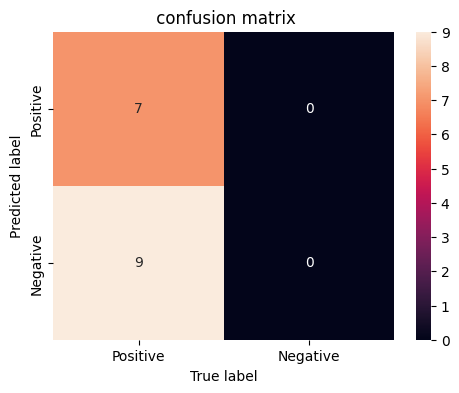

16/16 [==============================] - 0s 20ms/step
predicted_true_label
2561431_20230928_CT_7_19_19.jpg
2561431_20230928_CT_7_20_20.jpg
2561431_20230928_CT_7_21_21.jpg
2561431_20230928_CT_7_22_22.jpg
2561431_20230928_CT_7_24_24.jpg
2561431_20230928_CT_7_25_25.jpg
2561431_20230928_CT_7_26_26.jpg
2561431_20230928_CT_7_27_27.jpg
2561431_20230928_CT_7_28_28.jpg
2561431_20230928_CT_7_29_29.jpg
2561431_20230928_CT_7_30_30.jpg
2561431_20230928_CT_7_31_31.jpg
2561431_20230928_CT_7_32_32.jpg
accuracy: 0.8125


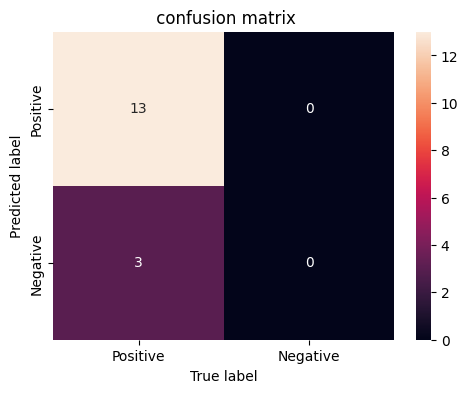

15/15 [==============================] - 0s 21ms/step
predicted_true_label
2644070_20240508_CT_4_20_20.jpg
2644070_20240508_CT_4_21_21.jpg
2644070_20240508_CT_4_22_22.jpg
2644070_20240508_CT_4_23_23.jpg
2644070_20240508_CT_4_24_24.jpg
2644070_20240508_CT_4_25_25.jpg
2644070_20240508_CT_4_26_26.jpg
2644070_20240508_CT_4_27_27.jpg
2644070_20240508_CT_4_28_28.jpg
2644070_20240508_CT_4_29_29.jpg
2644070_20240508_CT_4_30_30.jpg
2644070_20240508_CT_4_31_31.jpg
2644070_20240508_CT_4_32_32.jpg
2644070_20240508_CT_4_33_33.jpg
accuracy: 0.9333333333333333


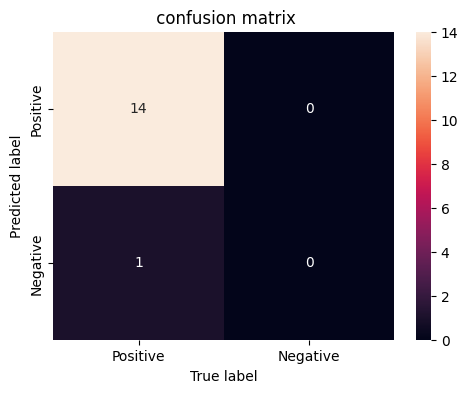

8/8 [==============================] - 0s 21ms/step
predicted_true_label
2679344_20231009_CT_6_21_21.jpg
2679344_20231009_CT_6_22_22.jpg
2679344_20231009_CT_6_23_23.jpg
2679344_20231009_CT_6_24_24.jpg
accuracy: 0.5


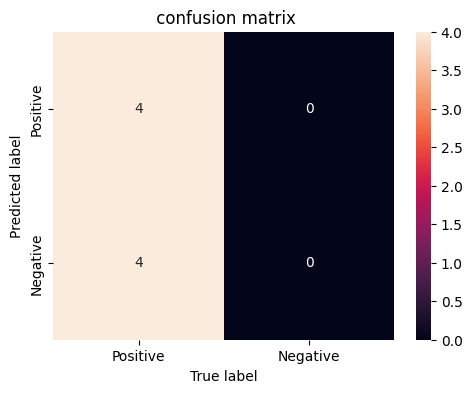

18/18 [==============================] - 0s 21ms/step
predicted_true_label
2718312_20240329_CT_4_20_20.jpg
2718312_20240329_CT_4_21_21.jpg
2718312_20240329_CT_4_22_22.jpg
2718312_20240329_CT_4_23_23.jpg
2718312_20240329_CT_4_24_24.jpg
2718312_20240329_CT_4_25_25.jpg
2718312_20240329_CT_4_28_28.jpg
2718312_20240329_CT_4_29_29.jpg
2718312_20240329_CT_4_30_30.jpg
2718312_20240329_CT_4_31_31.jpg
2718312_20240329_CT_4_32_32.jpg
2718312_20240329_CT_4_33_33.jpg
2718312_20240329_CT_4_34_34.jpg
2718312_20240329_CT_4_35_35.jpg
2718312_20240329_CT_4_36_36.jpg
2718312_20240329_CT_4_37_37.jpg
accuracy: 0.8888888888888888


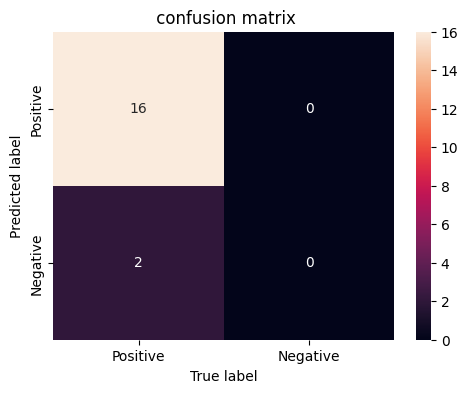

21/21 [==============================] - 0s 21ms/step
predicted_true_label
2780055_20230922_CT_4_24_24.jpg
2780055_20230922_CT_4_25_25.jpg
2780055_20230922_CT_4_26_26.jpg
2780055_20230922_CT_4_27_27.jpg
2780055_20230922_CT_4_28_28.jpg
2780055_20230922_CT_4_29_29.jpg
2780055_20230922_CT_4_30_30.jpg
2780055_20230922_CT_4_31_31.jpg
2780055_20230922_CT_4_32_32.jpg
2780055_20230922_CT_4_33_33.jpg
2780055_20230922_CT_4_34_34.jpg
2780055_20230922_CT_4_35_35.jpg
2780055_20230922_CT_4_36_36.jpg
2780055_20230922_CT_4_37_37.jpg
2780055_20230922_CT_4_38_38.jpg
accuracy: 0.7142857142857143


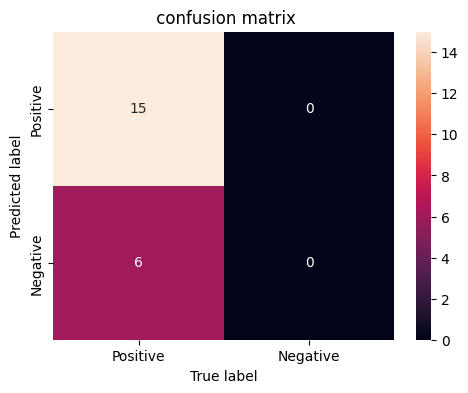

8/8 [==============================] - 0s 22ms/step
predicted_true_label
2823400_20240410_CT_7_24_24.jpg
2823400_20240410_CT_7_25_25.jpg
2823400_20240410_CT_7_26_26.jpg
2823400_20240410_CT_7_27_27.jpg
accuracy: 0.5


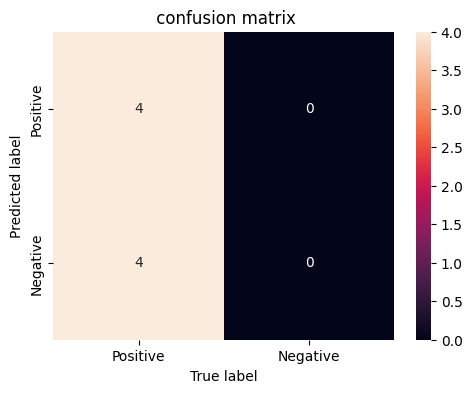

8/8 [==============================] - 0s 21ms/step
predicted_true_label
accuracy: 0.0


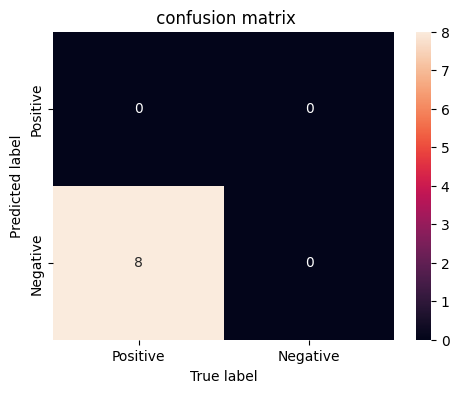

5/5 [==============================] - 0s 21ms/step
predicted_true_label
3168290_20230918_CT_2_22_22.jpg
3168290_20230918_CT_2_23_23.jpg
3168290_20230918_CT_2_24_24.jpg
3168290_20230918_CT_2_25_25.jpg
3168290_20230918_CT_2_26_26.jpg
accuracy: 1.0
3168290 預測正確
15/15 [==============================] - 0s 21ms/step
predicted_true_label
3177571_20240326_CT_4_24_24.jpg
3177571_20240326_CT_4_25_25.jpg
3177571_20240326_CT_4_26_26.jpg
3177571_20240326_CT_4_27_27.jpg
3177571_20240326_CT_4_28_28.jpg
3177571_20240326_CT_4_29_29.jpg
3177571_20240326_CT_4_30_30.jpg
3177571_20240326_CT_4_31_31.jpg
3177571_20240326_CT_4_32_32.jpg
3177571_20240326_CT_4_33_33.jpg
3177571_20240326_CT_4_34_34.jpg
3177571_20240326_CT_4_35_35.jpg
accuracy: 0.8


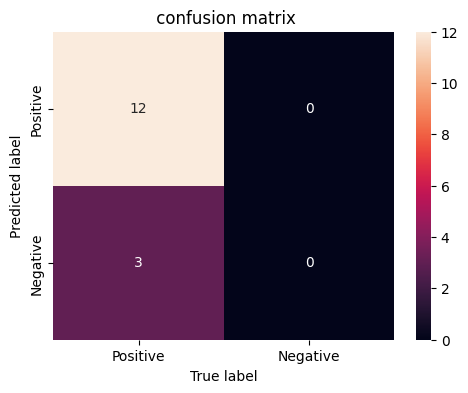

8/8 [==============================] - 0s 21ms/step
predicted_true_label
3201034_20240304_CT_4_23_21.jpg
3201034_20240304_CT_4_24_22.jpg
3201034_20240304_CT_4_25_23.jpg
3201034_20240304_CT_4_26_24.jpg
accuracy: 0.5


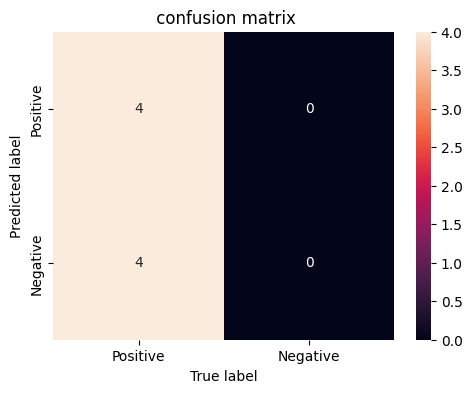

12/12 [==============================] - 0s 21ms/step
predicted_true_label
accuracy: 0.0


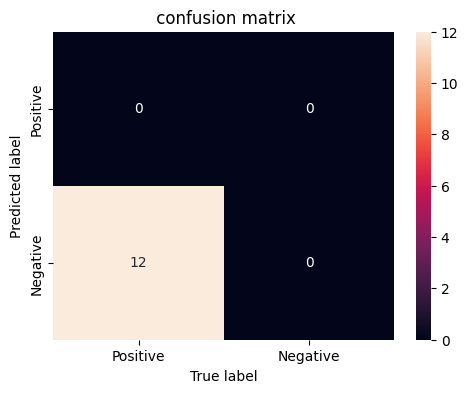

13/13 [==============================] - 0s 21ms/step
predicted_true_label
3247184_20240404_CT_4_35_33.jpg
3247184_20240404_CT_4_36_34.jpg
accuracy: 0.15384615384615385


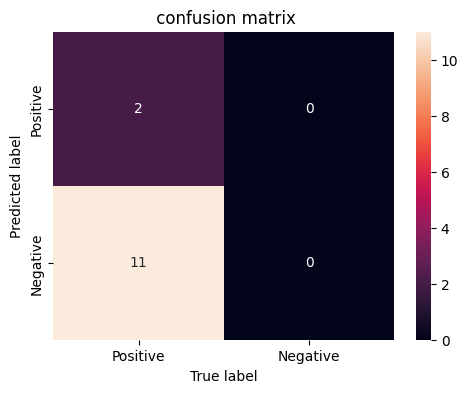

5/5 [==============================] - 0s 21ms/step
predicted_true_label
3315263_20240312_CT_2_20_20.jpg
accuracy: 0.2


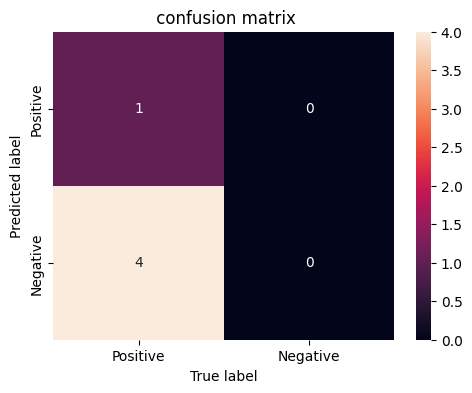

6/6 [==============================] - 0s 21ms/step
predicted_true_label
3345272_20240317_CT_4_22_22.jpg
3345272_20240317_CT_4_23_23.jpg
3345272_20240317_CT_4_24_24.jpg
accuracy: 0.5


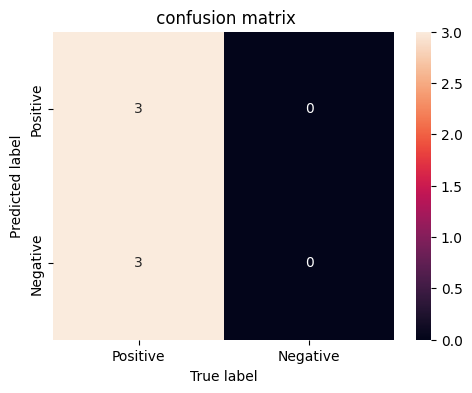

18/18 [==============================] - 0s 21ms/step
predicted_true_label
3374911_20240422_CT_4_34_31.jpg
3374911_20240422_CT_4_35_32.jpg
3374911_20240422_CT_4_36_33.jpg
3374911_20240422_CT_4_37_34.jpg
3374911_20240422_CT_4_38_35.jpg
3374911_20240422_CT_4_39_36.jpg
accuracy: 0.3333333333333333


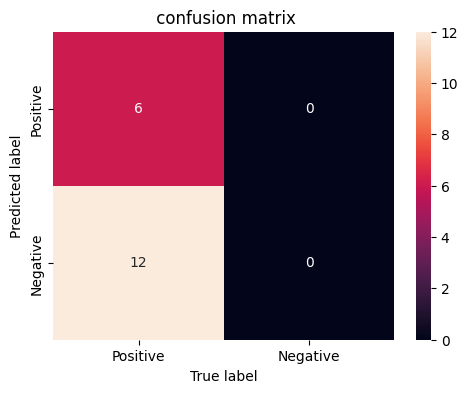

6/6 [==============================] - 0s 21ms/step
predicted_true_label
accuracy: 0.0


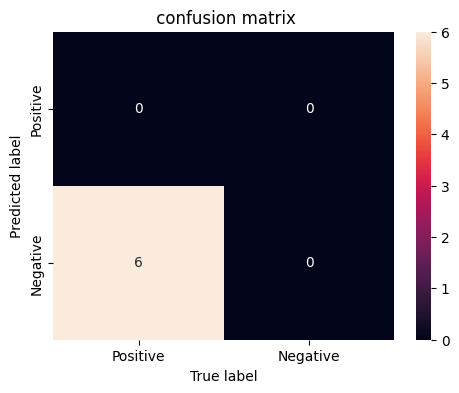

5/5 [==============================] - 0s 21ms/step
predicted_true_label
611383_20240506_CT_9_21_21.jpg
611383_20240506_CT_9_22_22.jpg
accuracy: 0.4


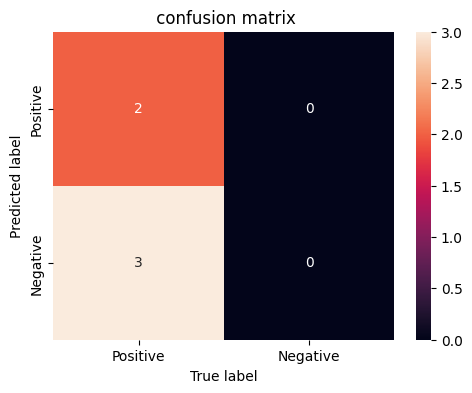

6/6 [==============================] - 0s 21ms/step
predicted_true_label
7004019_20230904_CT_4_29_29.jpg
7004019_20230904_CT_4_30_30.jpg
7004019_20230904_CT_4_31_31.jpg
accuracy: 0.5


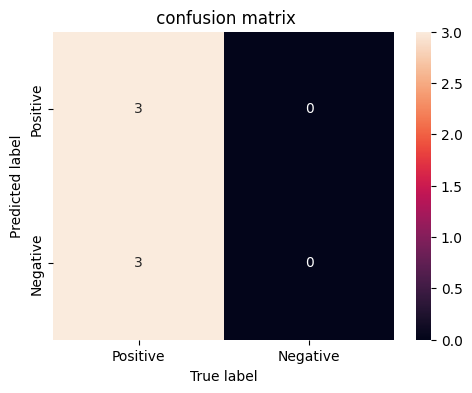

15/15 [==============================] - 0s 21ms/step
predicted_true_label
9013136_20230821_CT_4_18_18.jpg
9013136_20230821_CT_4_19_19.jpg
9013136_20230821_CT_4_20_20.jpg
9013136_20230821_CT_4_21_21.jpg
9013136_20230821_CT_4_22_22.jpg
9013136_20230821_CT_4_23_23.jpg
9013136_20230821_CT_4_24_24.jpg
9013136_20230821_CT_4_25_25.jpg
9013136_20230821_CT_4_26_26.jpg
9013136_20230821_CT_4_27_27.jpg
9013136_20230821_CT_4_28_28.jpg
9013136_20230821_CT_4_29_29.jpg
9013136_20230821_CT_4_30_30.jpg
9013136_20230821_CT_4_31_31.jpg
accuracy: 0.9333333333333333


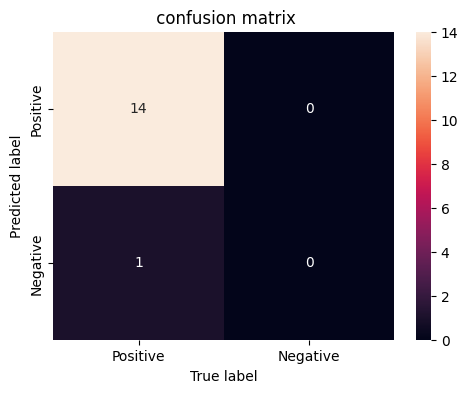

14/14 [==============================] - 0s 21ms/step
predicted_true_label
9013882_20230822_CT_4_21_21.jpg
9013882_20230822_CT_4_22_22.jpg
9013882_20230822_CT_4_23_23.jpg
9013882_20230822_CT_4_24_24.jpg
9013882_20230822_CT_4_25_25.jpg
9013882_20230822_CT_4_26_26.jpg
9013882_20230822_CT_4_27_27.jpg
9013882_20230822_CT_4_28_28.jpg
9013882_20230822_CT_4_29_29.jpg
accuracy: 0.6428571428571429


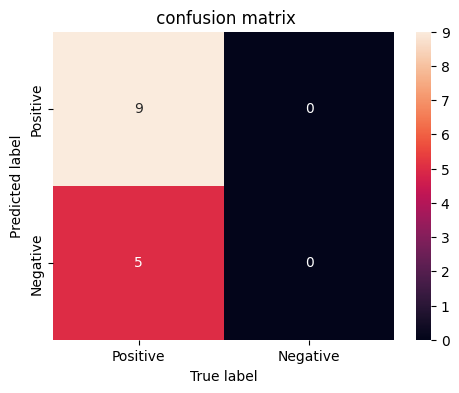

18/18 [==============================] - 0s 21ms/step
predicted_true_label
9015221_20230924_CT_4_23_23.jpg
9015221_20230924_CT_4_24_24.jpg
9015221_20230924_CT_4_25_25.jpg
9015221_20230924_CT_4_26_26.jpg
9015221_20230924_CT_4_27_27.jpg
9015221_20230924_CT_4_28_28.jpg
9015221_20230924_CT_4_29_29.jpg
9015221_20230924_CT_4_30_30.jpg
9015221_20230924_CT_4_31_31.jpg
9015221_20230924_CT_4_32_32.jpg
9015221_20230924_CT_4_33_33.jpg
9015221_20230924_CT_4_34_34.jpg
9015221_20230924_CT_4_35_35.jpg
9015221_20230924_CT_4_36_36.jpg
9015221_20230924_CT_4_37_37.jpg
9015221_20230924_CT_4_38_38.jpg
9015221_20230924_CT_4_39_39.jpg
accuracy: 0.9444444444444444


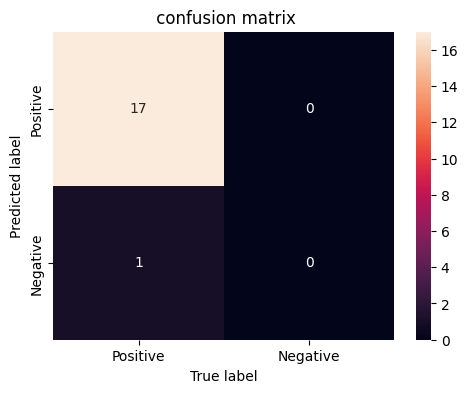

29/29 [==============================] - 1s 21ms/step
predicted_true_label
9015375_20230922_CT_4_23_20.jpg
9015375_20230922_CT_4_24_21.jpg
9015375_20230922_CT_4_25_22.jpg
9015375_20230922_CT_4_26_23.jpg
9015375_20230922_CT_4_27_24.jpg
9015375_20230922_CT_4_28_25.jpg
9015375_20230922_CT_4_29_26.jpg
9015375_20230922_CT_4_30_27.jpg
9015375_20230922_CT_4_31_28.jpg
9015375_20230922_CT_4_32_29.jpg
9015375_20230922_CT_4_33_30.jpg
9015375_20230922_CT_4_34_31.jpg
9015375_20230922_CT_4_35_32.jpg
9015375_20230922_CT_4_36_33.jpg
9015375_20230922_CT_4_37_34.jpg
9015375_20230922_CT_4_38_35.jpg
9015375_20230922_CT_4_39_36.jpg
9015375_20230922_CT_4_40_37.jpg
9015375_20230922_CT_4_41_38.jpg
9015375_20230922_CT_4_42_39.jpg
9015375_20230922_CT_4_43_40.jpg
9015375_20230922_CT_4_44_41.jpg
9015375_20230922_CT_4_45_42.jpg
accuracy: 0.7931034482758621


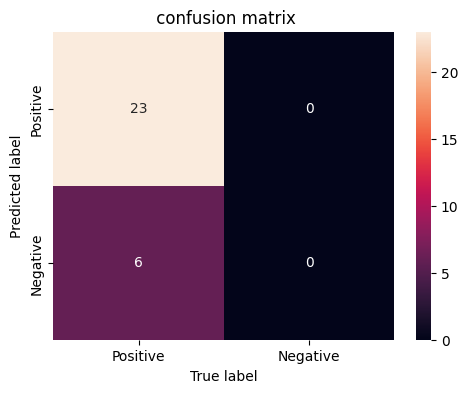

13/13 [==============================] - 0s 21ms/step
predicted_true_label
9016244_20231008_CT_4_26_26.jpg
accuracy: 0.07692307692307693


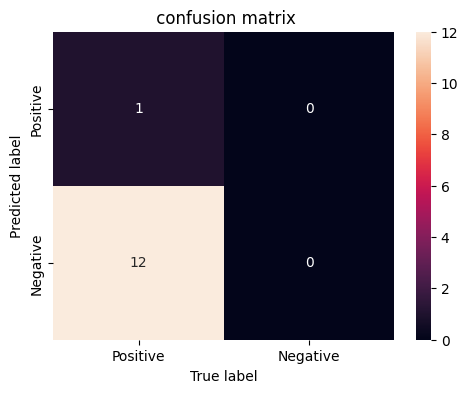

9/9 [==============================] - 0s 21ms/step
predicted_true_label
9028539_20240427_CT_4_30_30.jpg
accuracy: 0.1111111111111111


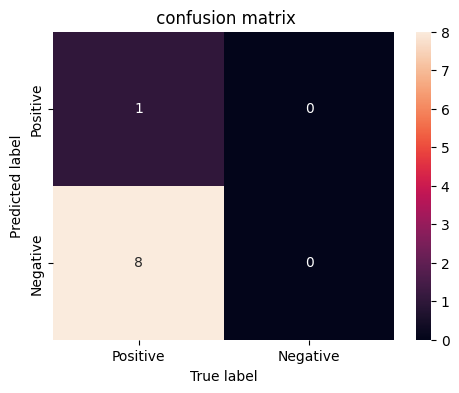

11/11 [==============================] - 0s 20ms/step
predicted_true_label
9029951_20240328_CT_7_30_30.jpg
accuracy: 0.09090909090909091


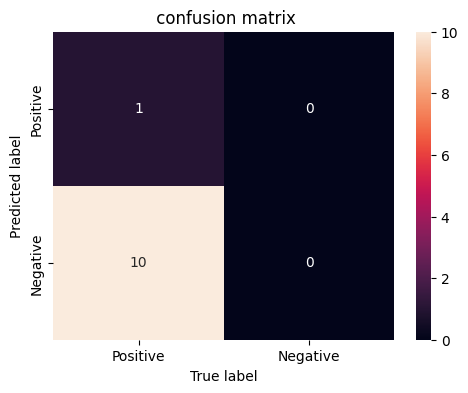

17/17 [==============================] - 0s 21ms/step
predicted_true_label
9032639_20240509_CT_4_24_24.jpg
9032639_20240509_CT_4_29_29.jpg
9032639_20240509_CT_4_30_30.jpg
accuracy: 0.17647058823529413


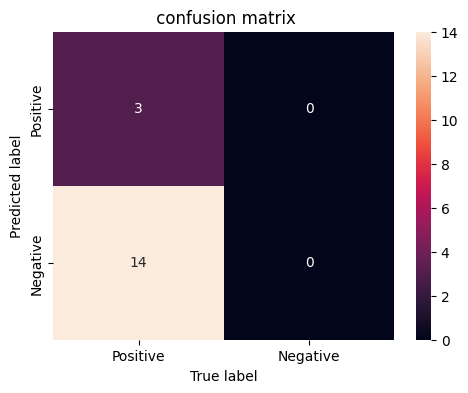

16/16 [==============================] - 0s 21ms/step
predicted_true_label
9040748_20240513_CT_4_31_31.jpg
9040748_20240513_CT_4_32_32.jpg
9040748_20240513_CT_4_33_33.jpg
accuracy: 0.1875


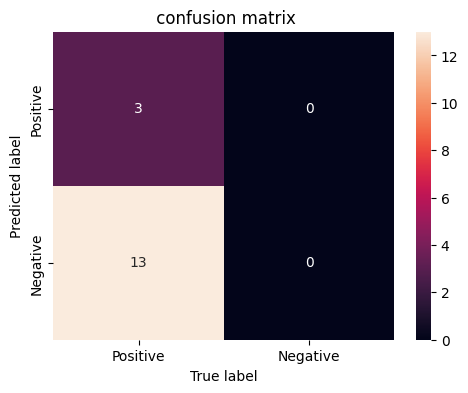

10/10 [==============================] - 0s 21ms/step
predicted_true_label
9041901_20240521_CT_4_25_25.jpg
9041901_20240521_CT_4_26_26.jpg
9041901_20240521_CT_4_27_27.jpg
9041901_20240521_CT_4_28_28.jpg
9041901_20240521_CT_4_29_29.jpg
9041901_20240521_CT_4_30_30.jpg
accuracy: 0.6


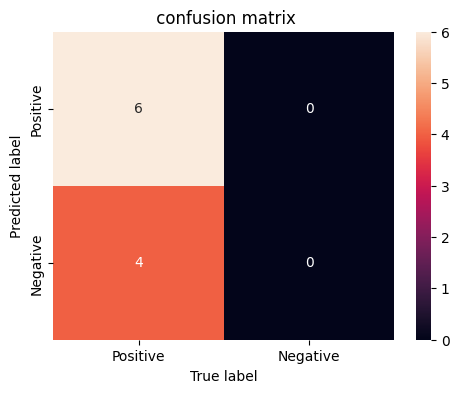

15/15 [==============================] - 0s 21ms/step
predicted_true_label
9042037_20240522_CT_4_24_22.jpg
9042037_20240522_CT_4_25_23.jpg
9042037_20240522_CT_4_26_24.jpg
9042037_20240522_CT_4_27_25.jpg
accuracy: 0.26666666666666666


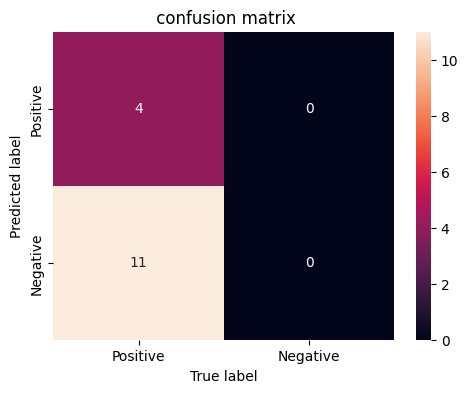

18/18 [==============================] - 0s 21ms/step
predicted_true_label
9042538_20240525_CT_4_22_22.jpg
9042538_20240525_CT_4_26_26.jpg
9042538_20240525_CT_4_27_27.jpg
9042538_20240525_CT_4_28_28.jpg
9042538_20240525_CT_4_29_29.jpg
9042538_20240525_CT_4_31_31.jpg
9042538_20240525_CT_4_32_32.jpg
9042538_20240525_CT_4_33_33.jpg
9042538_20240525_CT_4_34_34.jpg
9042538_20240525_CT_4_35_35.jpg
9042538_20240525_CT_4_36_36.jpg
accuracy: 0.6111111111111112


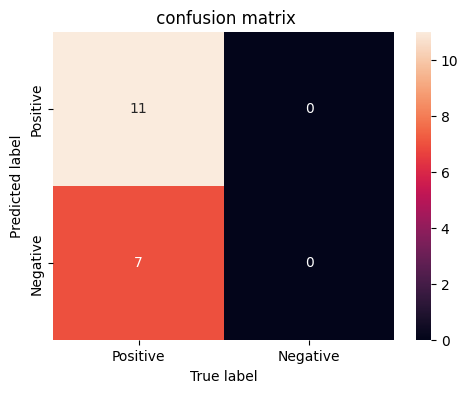

10/10 [==============================] - 0s 21ms/step
predicted_true_label
919300_20240527_CT_4_21_21.jpg
919300_20240527_CT_4_22_22.jpg
919300_20240527_CT_4_23_23.jpg
919300_20240527_CT_4_24_24.jpg
919300_20240527_CT_4_25_25.jpg
919300_20240527_CT_4_26_26.jpg
919300_20240527_CT_4_27_27.jpg
919300_20240527_CT_4_28_28.jpg
accuracy: 0.8


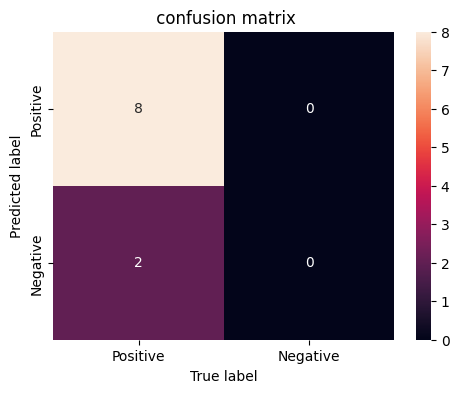

all_test
all_accuracy: 0.5532591414944356


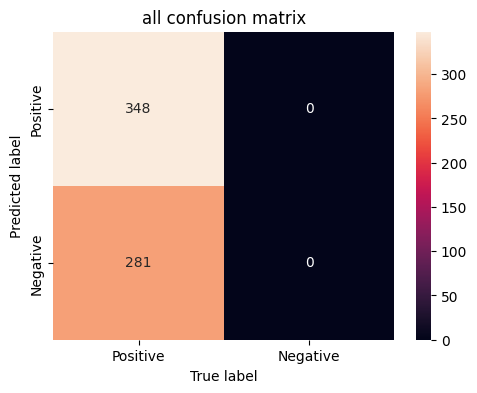

預測急性膽囊炎陽性
042736
1076468
1170119
1276685
1482601
1539408
1581895
1758897
1760107
1842545
2030899
2099286
2117512
2180217
2254047
2305923
2370624
2409545
2469358
2561431
2644070
2679344
2718312
2780055
2823400
3168290
3177571
3201034
3247184
3315263
3345272
3374911
611383
7004019
9013136
9013882
9015221
9015375
9016244
9028539
9029951
9032639
9040748
9041901
9042037
9042538
919300
預測急性膽囊炎陰性
1175553
1584102
3042030
3204229
3437297


In [17]:
first_folder="./test_case/LC/"
folder=os.listdir(first_folder)
all_true_classes=[]
all_predicted_classes=[]
LC_AP_class=[]
LC_LC_class=[]
for test in folder:
    bool_num=False
    true_classes=[]
    
    true_label_folder="./test_case/LC/{}/LC".format(test)
    true_files=[file for file in os.listdir(true_label_folder) if file.lower().endswith('.jpg')]
    file_num=(len(true_files))

    test_data_folder="./test_case/LC/{}/image".format(test)
    test_files=[file for file in os.listdir(test_data_folder) if file.lower().endswith('.jpg')]
    test_predict_gen = test_predict_generator(test_files, test_data_folder,target_size=(224,224))
    
    results = model.predict_generator(test_predict_gen, len(test_files), verbose=1)
    
    threshold = 0.85  # 可以根据需要调整
    
    # 将预测结果解释为类别
    predicted_classes = [1 if result > threshold else 0 for result in results]
    #print(test_files)
    #print("false_label")
    a=1
    for i in range(0,file_num):
        file_name=test_files[i]
        if file_name in true_files:
            #print(a,file_name)
            #print(results[i])
            true_classes.append(1)
        else:
            true_classes.append(0)
        a+=1
    print("predicted_true_label")
    index=0
    for i in predicted_classes:
        if i==1:
            print(test_files[index])
        index=index+1
    for i in predicted_classes:
        if i==1:
            bool_num=True
            break
    if bool_num:
        LC_LC_class.append(test)
    else:
        LC_AP_class.append(test)
    accuracy = accuracy_score(true_classes, predicted_classes)
    print("accuracy:",accuracy)
    all_true_classes=all_true_classes+true_classes
    all_predicted_classes=all_predicted_classes+predicted_classes

    #recall = recall_score(true_classes, predicted_classes)
    #print("recall:",recall)
    try:
        plot_CM(true_classes, predicted_classes," confusion matrix")
        
        
    except:
        print(test,"預測正確")        
        pass
    
print("all_test")
accuracy = accuracy_score(all_true_classes, all_predicted_classes)
print("all_accuracy:",accuracy)
#recall = recall_score(all_true_classes, all_predicted_classes)
#print("all_recall:",recall)
plot_CM(all_true_classes, all_predicted_classes,"all confusion matrix")
print("預測急性膽囊炎陽性")
for i in LC_LC_class:
    print(i)
print("預測急性膽囊炎陰性")
for i in LC_AP_class:
    print(i)

## Test CM (Case)

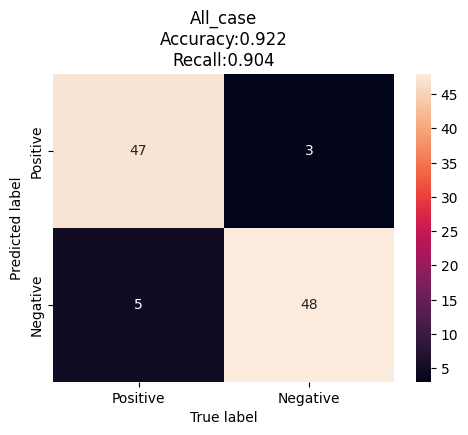

In [18]:
t

# ROC curve

In [11]:
thresholds=[]
for i in range(0,21):
    thresholds.append(round(1-0.05*i,2))

print(thresholds)

TP=[]
TN=[]
FP=[]
FN=[]
for threshold in thresholds:
    first_folder="./test_case/AP/"
    folder=os.listdir(first_folder)
    all_true_classes=[]
    all_predicted_classes=[]
    AP_AP_class=[]
    AP_LC_class=[]
    for test in folder:
        bool_num=False
        true_classes=[]
        false_label_folder="./test_case/AP/{}/AP".format(test)
        false_files=[file for file in os.listdir(false_label_folder) if file.lower().endswith('.jpg')]
        file_num=(len(false_files))

        test_data_folder="./test_case/AP/{}/image".format(test)
        test_files=[file for file in os.listdir(test_data_folder) if file.lower().endswith('.jpg')]
        test_predict_gen = test_predict_generator(test_files, test_data_folder,target_size=(224,224))
    
        results = model.predict_generator(test_predict_gen, len(test_files), verbose=1)
    
    
        # 将预测结果解释为类别
        predicted_classes = [1 if result > threshold else 0 for result in results]
        for i in range(0,file_num):
            file_name=test_files[i]
            if file_name in false_files:

                true_classes.append(0)
            else:
                true_classes.append(1)
        for i in predicted_classes:
            if i==1:
                bool_num=True
                break
        if bool_num:
            AP_LC_class.append(test)
        else:
            AP_AP_class.append(test)
    first_folder="./test_case/LC/"
    folder=os.listdir(first_folder)
    all_true_classes=[]
    all_predicted_classes=[]
    LC_AP_class=[]
    LC_LC_class=[]
    for test in folder:
        bool_num=False
        true_classes=[]
    
        true_label_folder="./test_case/LC/{}/LC".format(test)
        true_files=[file for file in os.listdir(true_label_folder) if file.lower().endswith('.jpg')]
        file_num=(len(true_files))

        test_data_folder="./test_case/LC/{}/image".format(test)
        test_files=[file for file in os.listdir(test_data_folder) if file.lower().endswith('.jpg')]
        test_predict_gen = test_predict_generator(test_files, test_data_folder,target_size=(224,224))
    
        results = model.predict_generator(test_predict_gen, len(test_files), verbose=1)

        predicted_classes = [1 if result > threshold else 0 for result in results]
        for i in range(0,file_num):
            file_name=test_files[i]
            if file_name in true_files:
                true_classes.append(1)
            else:
                true_classes.append(0)

        for i in predicted_classes:
            if i==1:
                bool_num=True
                break
        if bool_num:
            LC_LC_class.append(test)
        else:
            LC_AP_class.append(test)
    
    TP.append(len(LC_LC_class))
    TN.append(len(AP_AP_class))
    FP.append(len(AP_LC_class))
    FN.append(len(LC_AP_class))

[1.0, 0.95, 0.9, 0.85, 0.8, 0.75, 0.7, 0.65, 0.6, 0.55, 0.5, 0.45, 0.4, 0.35, 0.3, 0.25, 0.2, 0.15, 0.1, 0.05, 0.0]
10/10 [==============================] - 0s 21ms/step


16/16 [==============================] - 0s 21ms/step


17/17 [==============================] - 0s 21ms/step


11/11 [==============================] - 0s 21ms/step


9/9 [==============================] - 0s 21ms/step


13/13 [==============================] - 0s 21ms/step


29/29 [==============================] - 1s 21ms/step


10/10 [==============================] - 0s 22ms/step


[ 0  1  2  3  4  6  7 10 10 12 13 14 19 22 23 26 27 33 38 48 51]
[0.         0.71153846 0.86538462 0.90384615 0.90384615 0.92307692
 0.94230769 0.96153846 0.96153846 0.96153846 0.96153846 0.98076923
 0.98076923 1.         1.         1.         1.         1.
 1.         1.         1.        ]
[0.         0.01960784 0.03921569 0.05882353 0.07843137 0.11764706
 0.1372549  0.19607843 0.19607843 0.23529412 0.25490196 0.2745098
 0.37254902 0.43137255 0.45098039 0.50980392 0.52941176 0.64705882
 0.74509804 0.94117647 1.        ]


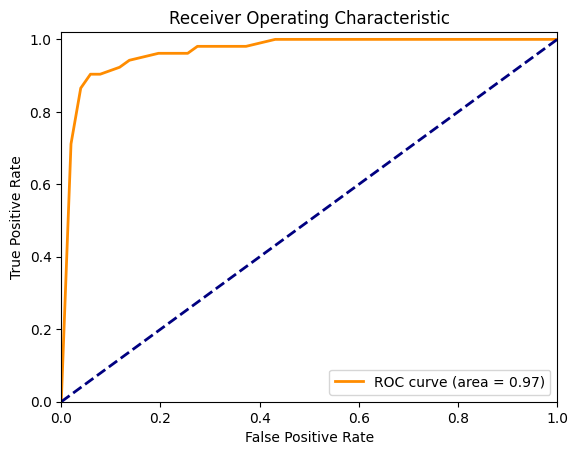

In [12]:
TP=np.array(TP)
TN=np.array(TN)
FP=np.array(FP)
FN=np.array(FN)
print(FP)
tpr=TP/(TP+FN)
fpr=FP/(FP+TN)
print(tpr)
print(fpr)
roc_auc = auc(fpr, tpr)

# 绘制 ROC 曲线
plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange',
         lw=lw, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.02])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()